In [1]:
%load_ext autoreload
%autoreload 2

### Pull Data

In [2]:
import os, json, sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(os.path.dirname(os.getcwd()))

from utils import DATA_DIR, ROOT_DIR
from utils.comet_utils import plot_all_metrics
from utils.comet_utils import fetch_experiments_by_run_name

with open(f'{ROOT_DIR}/.comet-api-key', 'r') as f: api_key = f.read().strip()

workspace = 'ai2'
project = 'peteish32'
run_name = 'peteish32'

if not os.path.exists(f'{DATA_DIR}/peteish32.json'):
    experiments = fetch_experiments_by_run_name(
        api_key=api_key,
        workspace=workspace,
        project_name=project,
        run_name=run_name
    )

    with open(f'{DATA_DIR}/peteish32.json', 'w') as f:
        json.dump(experiments, f, indent=2)

In [3]:
# Get combined results for all metrics
def process_experiment_file(experiments):
    metric_names = set()
    for exp in experiments:
        metric_names.update(exp['metrics'].keys())
    metric_names = list(metric_names)

    metric_data = {}
    for metric_name in sorted(metric_names):
        clean_name = metric_name.replace('eval/downstream/', '')\
                            .replace('/', '_')\
                            .replace(' ', '_')\
                            .lower()
        
        all_data = []
        for exp in experiments:
            if metric_name in exp['metrics']:
                df = pd.DataFrame({
                    'step': exp['step'][metric_name],
                    'value': exp['metrics'][metric_name]
                })
                all_data.append(df)
        
        if all_data:
            combined_df = pd.concat(all_data, ignore_index=True)
            metric_data[clean_name] = {
                'steps': combined_df['step'].tolist(),
                'values': combined_df['value'].tolist()
            }
    return metric_data

In [4]:
with open(f'{DATA_DIR}/peteish32.json', 'r') as f:
    experiments = json.load(f)

metric_data = process_experiment_file(experiments)

In [5]:
import json
import pandas as pd

# Save to json
with open(f'{DATA_DIR}/peteish32_processed.json', "w") as json_file:
    json.dump(metric_data, json_file)

# Save to csv
df = pd.DataFrame(metric_data).T
df = df.explode(["steps", "values"]).reset_index()
df = df.drop_duplicates(subset=["steps", "index"], keep="first")
df = df.pivot(index="steps", columns="index", values="values").sort_index()
csv_file_path = f'{DATA_DIR}/peteish32_processed.csv'
df.to_csv(csv_file_path)

### Analysis

In [25]:
from plot import plot_training
from stats import calc_total_variation, calc_improvement, calculate_standard_error, calc_improvement_last_n

def compute_total_variation(metric_data, metric, ax=None, color=None, sma_window=None, add_text=True):
    step, acc = metric_data[metric]['steps'], metric_data[metric]['values']

    tv = calc_total_variation(acc, improvement=True) * 100
    filtered_acc = [a for s, a in zip(step, acc) if 100000 < s < 240000]
    improvement = calc_improvement_last_n(filtered_acc, n=5) * len(filtered_acc)

    if ax is not None:
        _ = plot_training(
            ax, 
            step, acc,
            xlabel='step', ylabel='value',
            sma_window=sma_window,
            label=metric,
            title='peteish32',
            color=(color[j] if isinstance(color, list) else color)
        )

        if add_text:
            # Add total variation text
            text = ''
            text += f'\nTV-I={tv:.3f}'
            text = text.lstrip('\n')
            if text != '':
                ax.text(
                    x=step[-1], y=acc[-1], s=text, color=(color[j] if isinstance(color, list) else color), 
                    va='center', ha='left', zorder=5, fontsize=10
                )

                if metric != 'c4_loss' and metric != 'll_per_char':
                    lines = ax.get_lines()
                    max_x = max(max(line.get_xdata()) for line in lines)
                    ax.set_xlim(right=max_x * 1.25)
        
        ax.legend(fontsize=6, loc='upper center', bbox_to_anchor=(0.5, -0.1))

    return tv, improvement

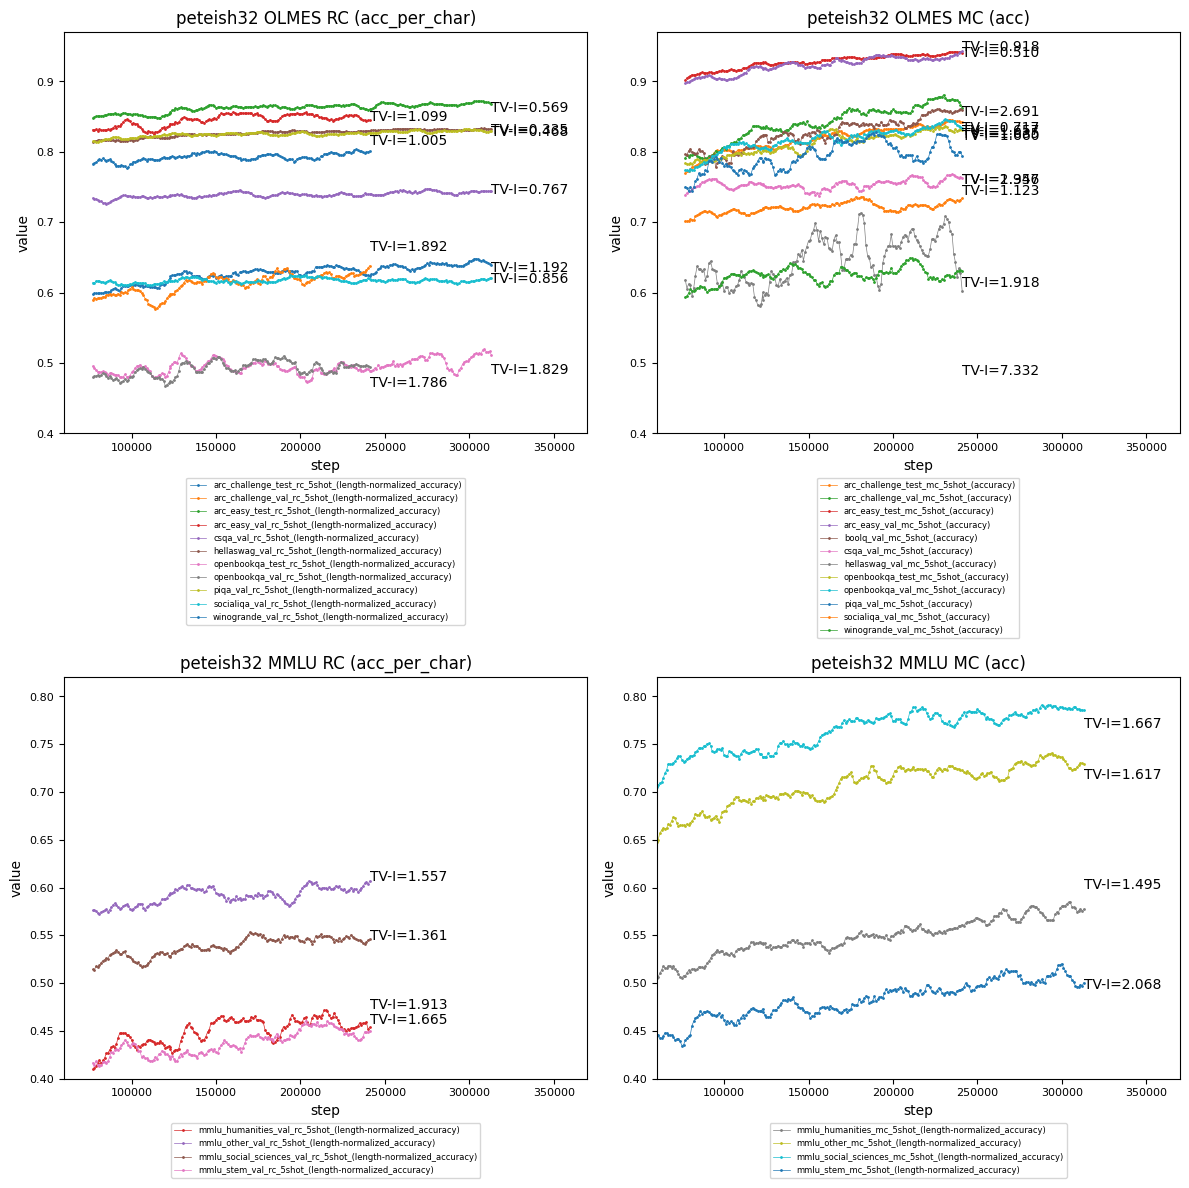

In [7]:
N_COLS = 2
N_ROWS = 2
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 6*N_ROWS), squeeze=False)

# SMA_WINDOW = None
SMA_WINDOW = 10

# Plot OLMES RC metrics (length-normalized accuracy)
ax = axes[0][0]
for metric_name, data in metric_data.items():
    if not all(['length-normalized_accuracy' in metric_name, 'mc' not in metric_name, any(x in metric_name for x in ['_val_', '_test_']), 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES RC (acc_per_char)')

# Plot OLMES MC metrics (accuracy)
ax = axes[0][1] 
for metric_name, data in metric_data.items():
    if not all(['accuracy' in metric_name, '_mc_' in metric_name, 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES MC (acc)')

# Plot MMLU RC metrics (length-normalized accuracy)
ax = axes[1][0]
for metric_name, data in metric_data.items():
    if not all(['length-normalized_accuracy' in metric_name, 'mc' not in metric_name, 'mmlu' in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 MMLU RC (acc_per_char)')

# Plot MMLU MC metrics (accuracy)
ax = axes[1][1]
for metric_name, data in metric_data.items():
    if not all(['accuracy' in metric_name, '_mc_' in metric_name,  'mmlu' in metric_name, '_val_' not in metric_name, 'test' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 MMLU MC (acc)')

# Set all axes to use same y range
for ax in axes[0]:
    ax.set_ylim(0.4, 0.97)
    ax.set_xlim(60_000, 370_000)
for ax in axes[1]:
    ax.set_ylim(0.4, 0.82)
    ax.set_xlim(60_000, 370_000)

plt.tight_layout()

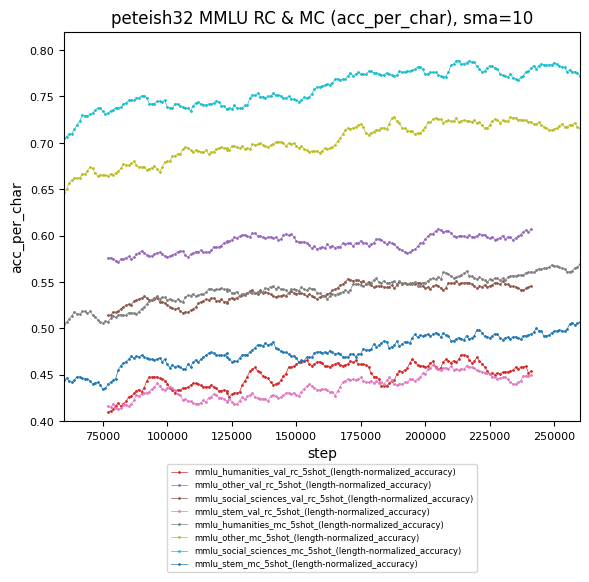

In [8]:
N_COLS = 1
N_ROWS = 1
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 6*N_ROWS), squeeze=False)

SMA_WINDOW = None
SMA_WINDOW = 10

# Plot MMLU RC metrics (length-normalized accuracy)
ax = axes[0][0]
for metric_name, data in metric_data.items():
    if not all(['length-normalized_accuracy' in metric_name, 'mc' not in metric_name, 'mmlu' in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW, add_text=False)

# Plot MMLU MC metrics (accuracy)
for metric_name, data in metric_data.items():
    if not all(['accuracy' in metric_name, '_mc_' in metric_name,  'mmlu' in metric_name, '_val_' not in metric_name, 'test' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW, add_text=False)

ax.set_title(f'peteish32 MMLU RC & MC (acc_per_char), sma={SMA_WINDOW}')
ax.set_ylabel(f'acc_per_char')

ax.set_ylim(0.4, 0.82)
ax.set_xlim(60_000, 260_000)

plt.tight_layout()

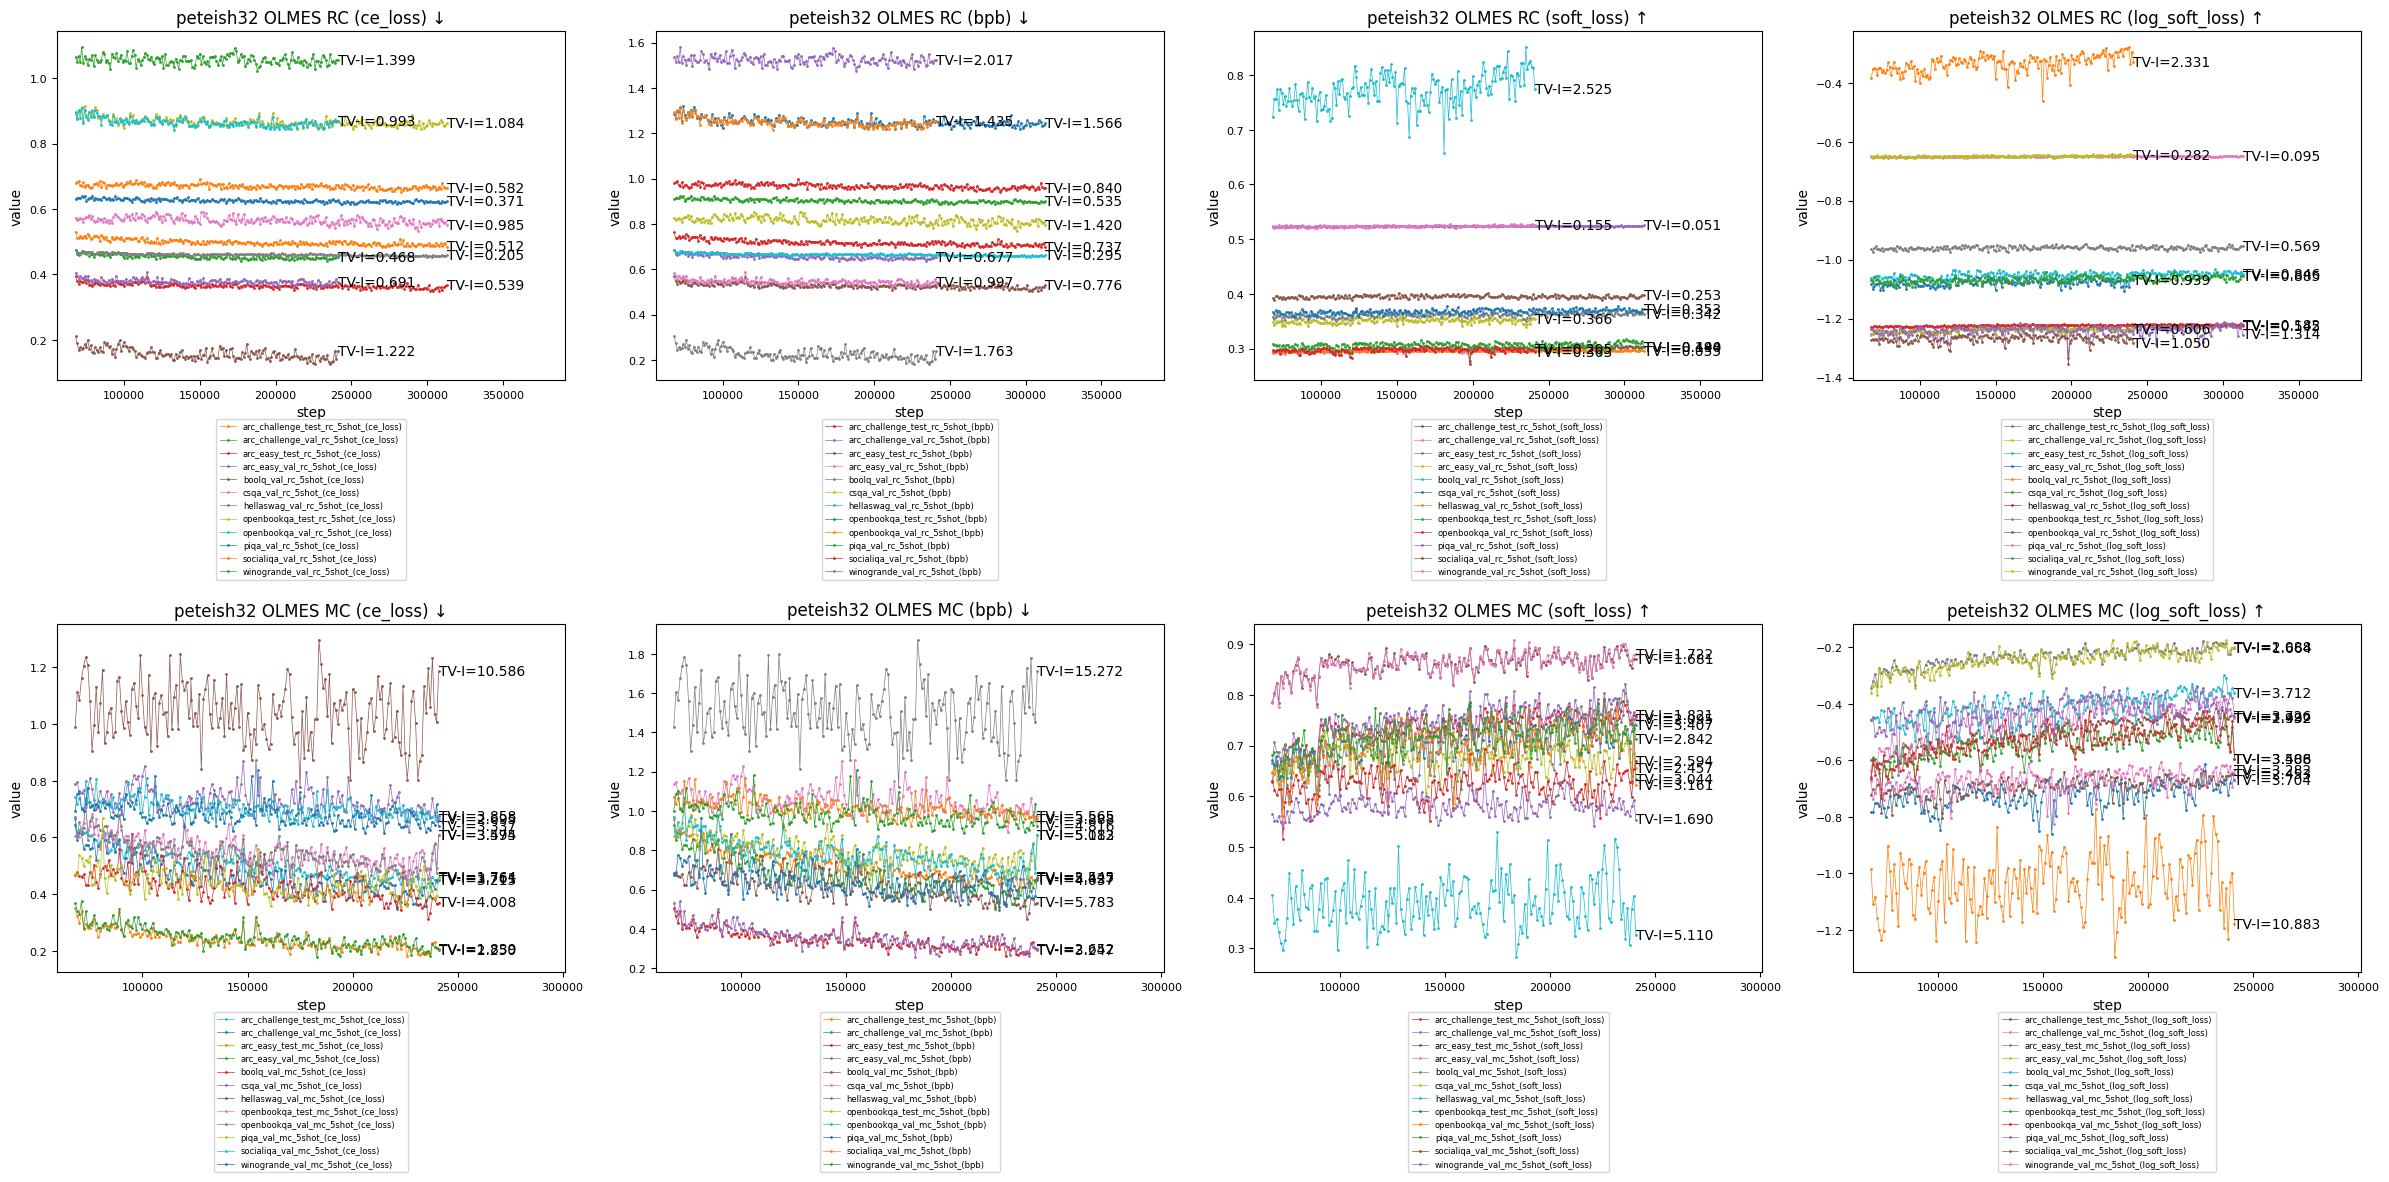

In [9]:
N_COLS = 4
N_ROWS = 2
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 6*N_ROWS), squeeze=False)

# SMA_WINDOW = 10
SMA_WINDOW = None

# Plot OLMES RC metrics (length-normalized accuracy)
ax = axes[0][0]
for metric_name, data in metric_data.items():
    if not all(['ce_loss' in metric_name, 'mc' not in metric_name, any(x in metric_name for x in ['_val_', '_test_']), 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES RC (ce_loss) ↓')

# Plot OLMES MC metrics (accuracy)
ax = axes[0][1] 
for metric_name, data in metric_data.items():
    if not all(['bpb' in metric_name, 'mc' not in metric_name, any(x in metric_name for x in ['_val_', '_test_']), 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES RC (bpb) ↓')

# Plot OLMES MC metrics (accuracy)
ax = axes[0][2] 
for metric_name, data in metric_data.items():
    if not all(['soft_loss' in metric_name, 'log_soft_loss' not in metric_name, 'mc' not in metric_name, any(x in metric_name for x in ['_val_', '_test_']), 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES RC (soft_loss) ↑')

# Plot OLMES MC metrics (accuracy)
ax = axes[0][3] 
for metric_name, data in metric_data.items():
    if not all(['log_soft_loss' in metric_name, 'mc' not in metric_name, any(x in metric_name for x in ['_val_', '_test_']), 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES RC (log_soft_loss) ↑')

# Plot OLMES MC metrics (accuracy)
ax = axes[1][0] 
for metric_name, data in metric_data.items():
    if not all(['ce_loss' in metric_name, '_mc_' in metric_name, 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES MC (ce_loss) ↓')

# Plot OLMES MC metrics (accuracy)
ax = axes[1][1] 
for metric_name, data in metric_data.items():
    if not all(['bpb' in metric_name, '_mc_' in metric_name, 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES MC (bpb) ↓')

# Plot OLMES MC metrics (accuracy)
ax = axes[1][2] 
for metric_name, data in metric_data.items():
    if not all(['soft_loss' in metric_name, 'log_soft_loss' not in metric_name, '_mc_' in metric_name, 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES MC (soft_loss) ↑')

# Plot OLMES MC metrics (accuracy)
ax = axes[1][3] 
for metric_name, data in metric_data.items():
    if not all(['log_soft_loss' in metric_name, '_mc_' in metric_name, 'mmlu' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES MC (log_soft_loss) ↑')

plt.tight_layout()

In [10]:
from tqdm import tqdm

rows = []
cols = []
tv_vals = []
i_vals = []

for metric_name, data in metric_data.items():
    # Extract the value in parentheses and the part before it
    import re
    match = re.search(r'(.*?)\s*\((.*?)\)', metric_name)
    if match:
        row = match.group(1).strip()
        col = match.group(2).strip()
        tv, i = compute_total_variation(metric_data, metric_name)
        
        rows.append(row)
        cols.append(col)
        tv_vals.append(tv)
        i_vals.append(i)

def process_df(rows, cols, values):
    df = pd.DataFrame(index=pd.unique(rows), columns=pd.unique(cols))
    for row, col, val in zip(rows, cols, values):
        df.loc[row, col] = val

    df['accuracy'] = df['length-normalized_accuracy'].combine_first(df['accuracy'])
    df = df.drop('length-normalized_accuracy', axis=1)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Separate RC and MC
    df = df[df.index.str.contains('_rc_|_mc_', case=False)]
    df_rc = df[df.index.str.contains('_rc_', case=False)]
    df_mc = df[df.index.str.contains('_mc_', case=False)]
    df_rc.index = df_rc.index.str.replace('_rc_', '_', regex=False)
    df_mc.index = df_mc.index.str.replace('_mc_', '_', regex=False)
    df_rc = df_rc.add_suffix('_rc')
    df_mc = df_mc.add_suffix('_mc')

    # Combine DFs
    total_variation = pd.concat([df_rc, df_mc], axis=1)
    total_variation = total_variation.dropna(subset=['accuracy_mc'])
    total_variation.loc['avg'] = total_variation.mean(numeric_only=True)
    total_variation['avg'] = total_variation.mean(axis=1, numeric_only=True)

    # # Sort the rows and cols
    # total_variation = total_variation.sort_values('avg', ascending=False)
    # total_variation = total_variation.loc[:, total_variation.loc['avg'].sort_values(ascending=False).index]

    return total_variation

total_variation = process_df(rows, cols, tv_vals)
improvement = process_df(rows, cols, i_vals)

/var/folders/cr/z51hvhb932vbx29jw5hxd9nh0000gn/T/ipykernel_3907/1772108156.py:23: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  df = pd.DataFrame(index=pd.unique(rows), columns=pd.unique(cols))
/var/folders/cr/z51hvhb932vbx29jw5hxd9nh0000gn/T/ipykernel_3907/1772108156.py:23: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  df = pd.DataFrame(index=pd.unique(rows), columns=pd.unique(cols))


In [11]:
print(f'TV-I for all tasks and metrics:')
total_variation.round(3)

TV-I for all tasks and metrics:


,bpb_rc,ce_loss_rc,log_soft_loss_rc,soft_loss_rc,accuracy_rc,bpb_mc,ce_loss_mc,log_soft_loss_mc,soft_loss_mc,accuracy_mc,avg
arc_challenge_test_5shot_,0.737,0.512,0.545,0.190,1.192,2.545,1.764,1.492,1.821,0.717,1.151
arc_challenge_val_5shot_,0.677,0.468,0.606,0.205,1.892,4.637,3.215,2.932,2.095,1.657,1.838
arc_easy_test_5shot_,0.776,0.539,0.846,0.342,0.569,2.652,1.839,1.664,1.681,0.510,1.142
arc_easy_val_5shot_,0.997,0.691,0.939,0.366,1.099,3.247,2.250,2.088,1.722,0.918,1.432
boolq_val_5shot_,1.763,1.222,2.331,2.525,0.998,5.783,4.008,3.712,3.407,2.691,2.844
csqa_val_5shot_,1.420,0.985,0.885,0.353,0.767,5.565,3.858,3.704,2.457,1.357,2.135
hellaswag_val_5shot_,0.295,0.205,0.182,0.055,0.335,15.272,10.586,10.883,5.110,7.332,5.025
mmlu_humanities_val_5shot_,0.626,0.437,0.315,0.088,1.913,3.452,2.391,2.284,1.367,1.902,1.478
mmlu_other_val_5shot_,1.055,0.733,0.536,0.184,1.557,3.254,2.253,2.110,1.761,1.551,1.500
mmlu_social_sciences_val_5shot_,0.632,0.439,0.385,0.120,1.361,3.870,2.682,2.541,2.015,1.600,1.564


In [12]:
print(f'Improvement for all tasks and metrics (for 100_000 < step < 240_000, avg. of 5 checkpoints):')
(improvement*100).round(3)

Improvement for all tasks and metrics (for 100_000 < step < 240_000, avg. of 5 checkpoints):


,bpb_rc,ce_loss_rc,log_soft_loss_rc,soft_loss_rc,accuracy_rc,bpb_mc,ce_loss_mc,log_soft_loss_mc,soft_loss_mc,accuracy_mc,avg
arc_challenge_test_5shot_,-1.774,-1.231,0.897,0.321,0.631,-17.901,-12.407,12.562,4.150,4.215,-1.054
arc_challenge_val_5shot_,-0.777,-0.537,0.708,0.264,4.348,-16.984,-11.773,12.196,4.903,5.151,-0.250
arc_easy_test_5shot_,-1.004,-0.699,0.110,-0.021,0.589,-8.147,-5.646,5.631,1.836,2.458,-0.489
arc_easy_val_5shot_,-0.630,-0.437,-0.037,-0.040,0.105,-11.595,-8.035,8.078,3.201,3.930,-0.546
boolq_val_5shot_,-5.449,-3.777,7.397,8.112,3.688,-13.494,-9.354,10.080,8.852,5.401,1.146
csqa_val_5shot_,-3.871,-2.683,0.530,0.103,0.459,-13.055,-9.046,9.502,-0.668,1.360,-1.737
hellaswag_val_5shot_,-0.526,-0.363,0.364,0.107,0.930,12.731,8.826,-8.893,-5.384,-3.131,0.466
mmlu_humanities_val_5shot_,-1.229,-0.844,0.321,0.116,1.892,-6.948,-4.818,4.799,2.092,2.664,-0.195
mmlu_other_val_5shot_,-1.931,-1.335,0.944,0.345,3.380,-8.006,-5.554,5.561,3.142,2.761,-0.069
mmlu_social_sciences_val_5shot_,-1.745,-1.210,0.591,0.151,2.849,-11.571,-8.028,8.482,4.326,4.570,-0.159


In [13]:
# Calculate TV-I on each metric
    # Compute average TV-I on each setup (accuracy vs. BPB vs. CE Loss, etc.)

# Calculate improvement slope after some number of training steps (seperate RC and MC)

# (maybe) try that metric that was fitted to the log curve

# (maybe) try to predict performance

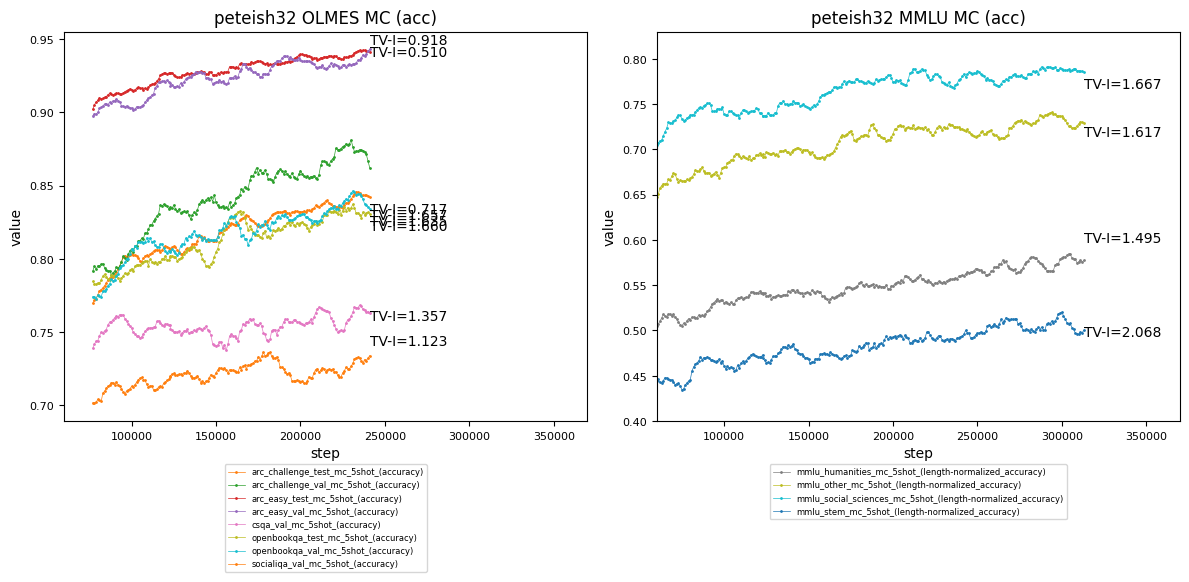

In [14]:
N_COLS = 2
N_ROWS = 1
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 6*N_ROWS), squeeze=False)

SMA_WINDOW = 10

# Plot OLMES MC metrics (accuracy)
ax = axes[0][0] 
for metric_name, data in metric_data.items():
    if not all(['accuracy' in metric_name, '_mc_' in metric_name, 'mmlu' not in metric_name, '5shot' in metric_name and not any(name in metric_name for name in ['hellaswag', 'boolq', 'piqa', 'winogrande'])]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 OLMES MC (acc)')

# Plot MMLU MC metrics (accuracy)
ax = axes[0][1]
for metric_name, data in metric_data.items():
    if not all(['accuracy' in metric_name, '_mc_' in metric_name,  'mmlu' in metric_name, '_val_' not in metric_name, 'test' not in metric_name, '5shot' in metric_name]): continue
    compute_total_variation(metric_data, metric_name, ax=ax, sma_window=SMA_WINDOW)
ax.set_title('peteish32 MMLU MC (acc)')

# Set all axes to use same y range
for ax in axes[0]:
    ax.set_xlim(60_000, 370_000)
axes[0][1].set_ylim(0.4, 0.83)

plt.tight_layout()

### Request from Jesse

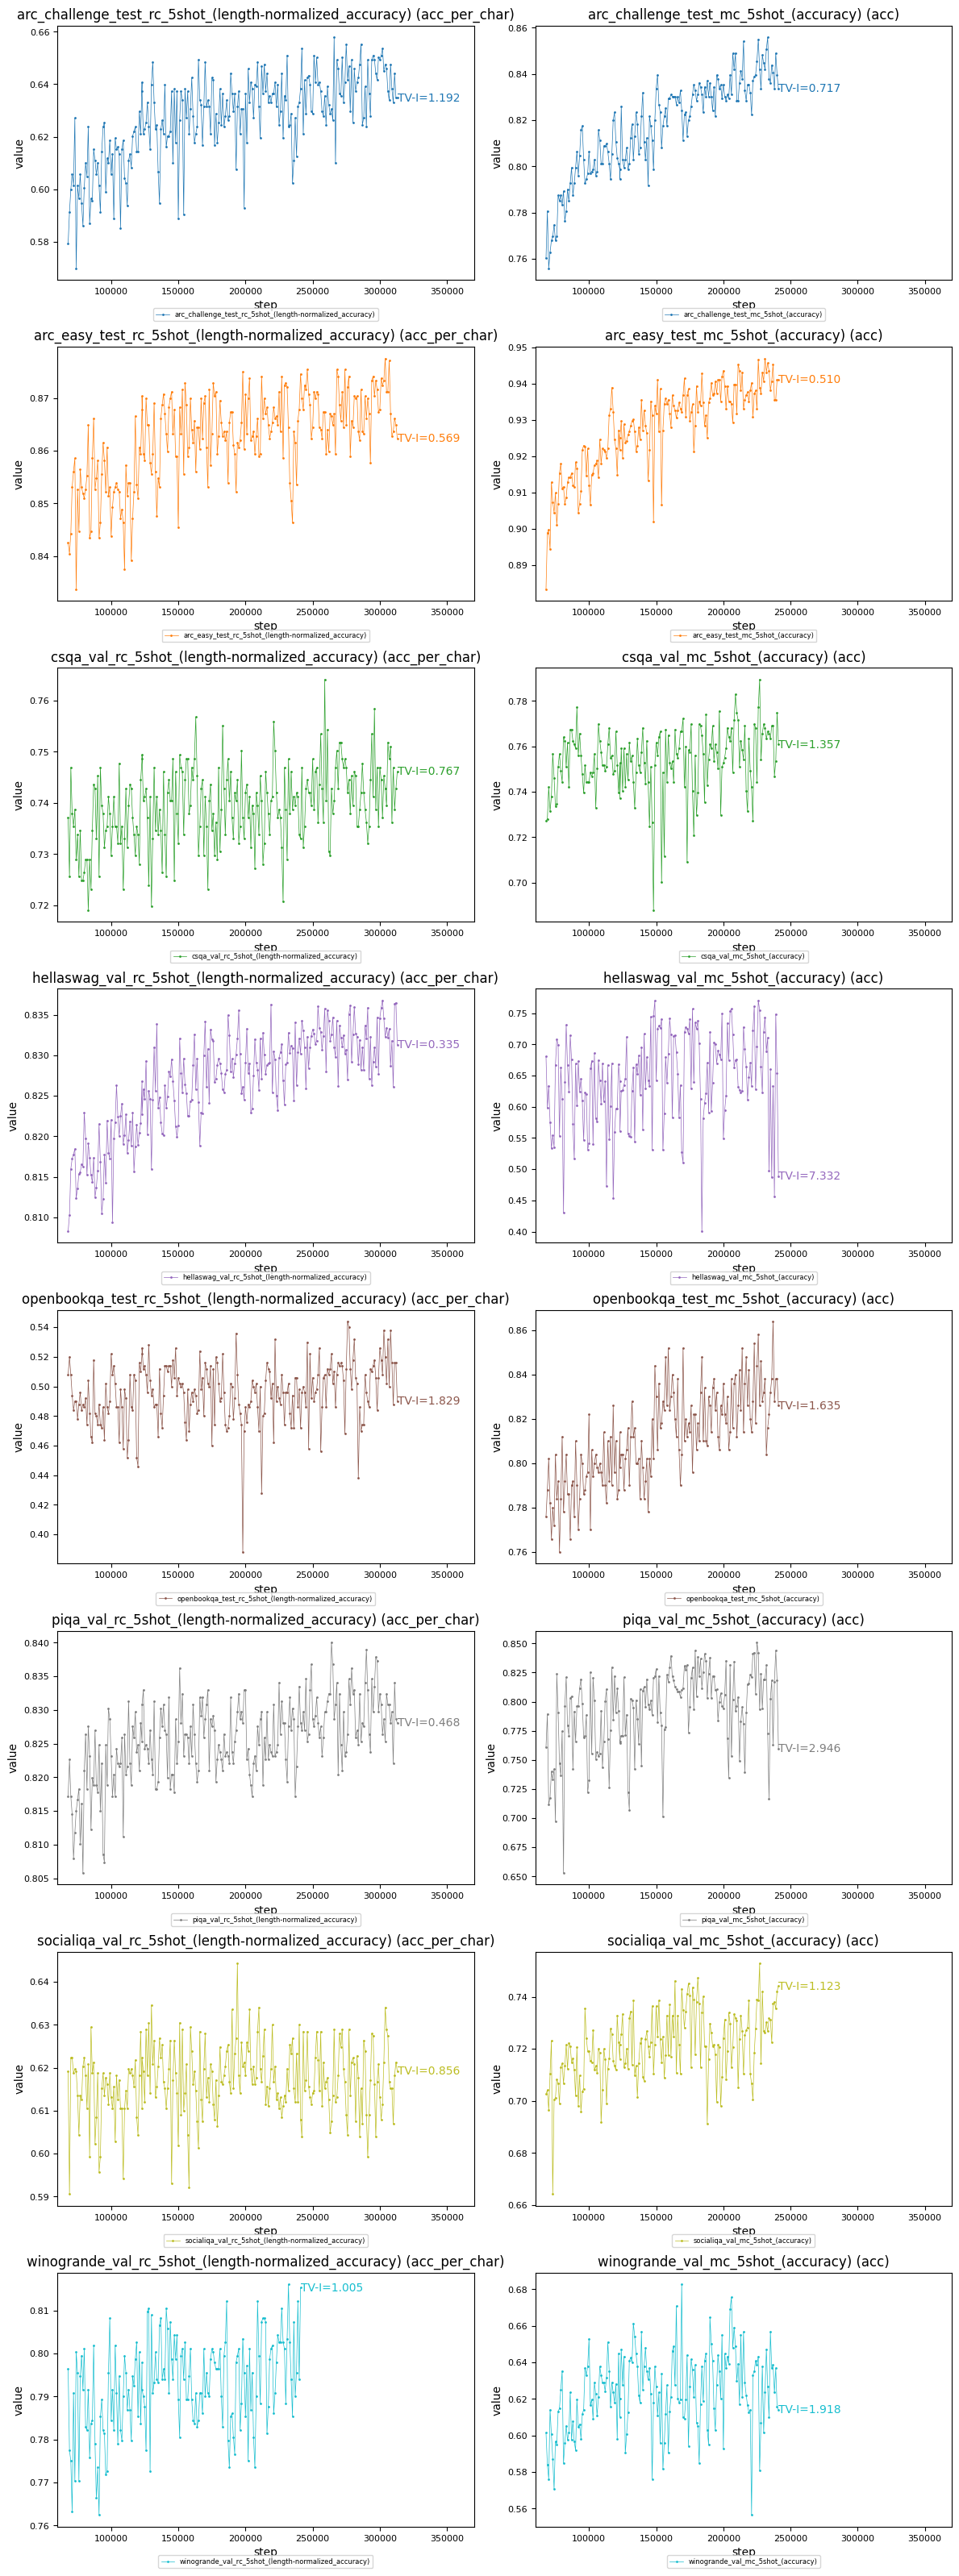

In [28]:
import numpy as np

SMA_WINDOW = None
# SMA_WINDOW = 10

# Create two sets of metrics to plot
set1_metrics = [
    metric for metric, _ in metric_data.items()
    if all(['length-normalized_accuracy' in metric,
            'mc' not in metric,
            any(x in metric for x in ['_val_', '_test_']),
            'mmlu' not in metric,
            '5shot' in metric])
]

set2_metrics = [
    metric for metric, _ in metric_data.items() 
    if all(['accuracy' in metric,
            '_mc_' in metric,
            'mmlu' not in metric,
            '5shot' in metric,
            'boolq' not in metric])
]

# Prioritize test metrics over validation metrics
def prioritize_test_metrics(metrics):
    result = {}
    for metric in metrics:
        task = metric.split('_val_')[0] if '_val_' in metric else metric.split('_test_')[0]
        if task not in result or '_test_' in metric:
            result[task] = metric
    return list(result.values())

set1_metrics = prioritize_test_metrics(set1_metrics)
set2_metrics = prioritize_test_metrics(set2_metrics)

# Create subplot grid
n_rows = max(len(set1_metrics), len(set2_metrics))
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4*n_rows), squeeze=False)

# Create color map
colors = plt.cm.tab10(np.linspace(0, 1, n_rows))

# Plot metrics
for idx, (metric, col) in enumerate([(set1_metrics, 0), (set2_metrics, 1)]):
    for row, m in enumerate(metric):
        ax = axes[row][col]
        compute_total_variation(metric_data, m, ax=ax, color=colors[row], sma_window=SMA_WINDOW)
        ax.set_title(f'{m} ({"acc_per_char" if col==0 else "acc"})')
        ax.set_xlim(60_000, 370_000)

# Hide empty subplots        
for i in range(len(set1_metrics), n_rows):
    axes[i][0].axis('off')
for i in range(len(set2_metrics), n_rows):
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()